---
# Initial Setup
1. Clone the repo
2. change directory
3. switch branches

In [1]:
!git clone https://github.com/Dewnan/NLP_Group_15.git
%cd NLP_Group_15
!git checkout feature/CIT-24-01-0020-model

Cloning into 'NLP_Group_15'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 354 (delta 70), reused 118 (delta 34), pack-reused 176 (from 1)
Receiving objects: 100% (354/354), 43.42 MiB | 17.82 MiB/s, done.
Resolving deltas: 100% (144/144), done.
/content/NLP_Group_15
Branch 'feature/CIT-24-01-0020-model' set up to track remote branch 'feature/CIT-24-01-0020-model' from 'origin'.
Switched to a new branch 'feature/CIT-24-01-0020-model'


---
**! Before Running the rest import the username and key from the Kaggle in to the colab secrets**
---

In [2]:
!pip install wordcloud

In [3]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from src.data_downloader import download_dataset
from src.preprocess import load_and_merge, build_content_and_clean, apply_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
dataset_path = download_dataset()
print(f'Dataset downloaded to: {dataset_path}')

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset downloaded to: data


---
**Process the data set**

In [5]:
try:
    if os.path.exists('data/processed'):
        shutil.rmtree('data/processed')
    os.mkdir('data/processed')
except Exception as e:
    print(f'Failed to remove existing data sets / create a folder: {e}')

try:
    merged_df = load_and_merge()
    merged_df.to_csv('data/processed/merged_news.csv', index=False)
except Exception as e:
    print(f'Failed to merge data sets: {e}')

try:
    cleaned_df = build_content_and_clean(merged_df)
    cleaned_df.to_csv('data/processed/cleaned_news.csv', index=False)
except Exception as e:
    print(f'Failed to clean data sets: {e}')

try:
    tokenize_and_lemmatize_df = apply_tokenize(cleaned_df)
    tokenize_and_lemmatize_df.to_csv('data/processed/tokenized_news.csv', index=False)
except Exception as e:
    print(f'Failed to tokenize data sets: {e}')

Dropped 6071 duplicate rows
Dropped 3 rows with empty or near empty content


# Exploratory Data Analysis

## Class distribution

Class Destribution after merging datasets

Class Counts: 
label
0    21417
1    23481
Name: count, dtype: int64

Real data count: 21417, Percentage: 47.7%
Fake data count: 23481, Percentage: 52.3%


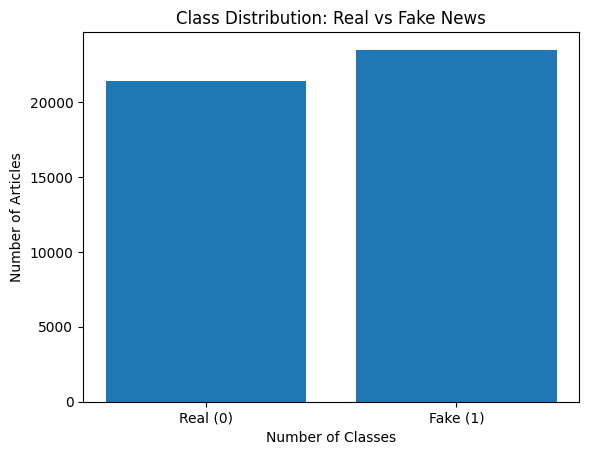

In [6]:
merged_df = pd.read_csv('data/processed/merged_news.csv')

class_counts = merged_df['label'].value_counts().sort_index()
print(f'Class Counts: \n{class_counts}\n')

real_count = class_counts[0]
fake_count = class_counts[1]
total = len(merged_df)

real_percent = real_count / total * 100
fake_percent = fake_count / total * 100

print(f"Real data count: {real_count}, Percentage: {real_percent:.1f}%")
print(f"Fake data count: {fake_count}, Percentage: {fake_percent:.1f}%")

plt.bar(['Real (0)', 'Fake (1)'], class_counts.values, width=0.8)
plt.title('Class Distribution: Real vs Fake News')
plt.xlabel('Number of Classes')
plt.ylabel('Number of Articles')
plt.show()

## Text Length Distribution

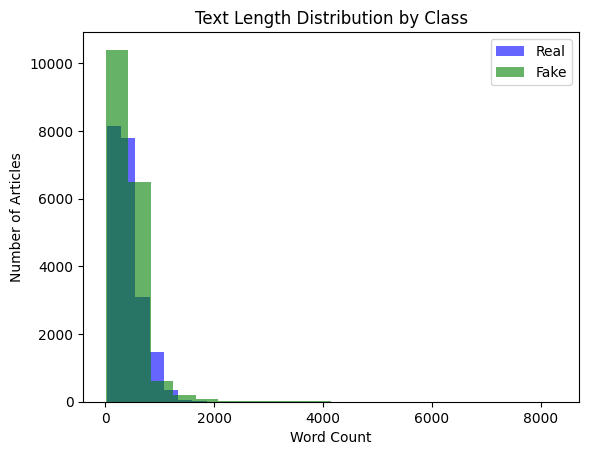

         count        mean         std   min    25%    50%    75%     max
label                                                                    
0      20925.0  397.788244  276.336073  29.0  159.0  371.0  536.0  5254.0
1      17899.0  431.103134  360.947465   6.0  281.0  387.0  516.0  8289.0


In [7]:
cleaned_df = pd.read_csv('data/processed/cleaned_news.csv')

def word_counter(text):
  words = str(text).split()
  return len(words)

cleaned_df['word_count'] = cleaned_df['content'].apply(word_counter)

real_article_Wcount = cleaned_df[cleaned_df['label'] == 0]['word_count']
fake_article_Wcount = cleaned_df[cleaned_df['label'] == 1]['word_count']

plt.hist(real_article_Wcount, bins=20, alpha=0.6, label='Real', color='blue')
plt.hist(fake_article_Wcount, bins=20, alpha=0.6, label='Fake', color='green')

plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.title('Text Length Distribution by Class')
plt.legend()
plt.show()

print(cleaned_df.groupby('label')['word_count'].describe())

Class distribution before and after data cleaning

In [8]:
print("Class distribution raw merged data:")
print(merged_df['label'].value_counts(normalize=True)*100)

print("\nClass distribution after cleaning:")
print(cleaned_df['label'].value_counts(normalize=True)*100)

Class distribution raw merged data:
label
1    52.298543
0    47.701457
Name: proportion, dtype: float64

Class distribution after cleaning:
label
0    53.897074
1    46.102926
Name: proportion, dtype: float64


## Word frequency analysis

In [9]:
from collections import Counter
tokenized_df = pd.read_csv('data/processed/tokenized_news.csv')

def get_top_words(text, word_count=20):
    all_words = ' '.join(text).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(word_count)

top_overall = get_top_words(tokenized_df['content'], word_count=20)
print("Top 20 words overall:")
for word, count in top_overall:
    print(f"{word}: {count}")

top_words_real = get_top_words(tokenized_df[tokenized_df['label'] == 0]['content'], word_count=20)
top_words_fake = get_top_words(tokenized_df[tokenized_df['label'] == 1]['content'], word_count=20)

print("\nTop 20 words in Real news:")
for word, count in top_words_real:
    print(f"{word}: {count}")

print("\nTop 20 words in Fake news:")
for word, count in top_words_fake:
    print(f"{word}: {count}")

Top 20 words overall:
trump: 134668
said: 121427
state: 54820
president: 50573
would: 49544
republican: 39224
people: 36798
year: 36722
one: 33665
new: 28449
house: 27083
also: 26956
government: 26617
donald: 26363
say: 25585
obama: 25091
clinton: 24912
time: 24493
election: 23227
country: 22490

Top 20 words in Real news:
said: 96473
trump: 58351
state: 37334
would: 31088
president: 28409
republican: 23747
year: 22403
government: 19889
house: 18120
new: 17402
also: 15527
party: 15433
people: 15129
election: 15104
united: 14936
official: 14622
told: 13882
country: 13797
could: 13600
one: 13587

Top 20 words in Fake news:
trump: 76317
said: 24954
president: 22164
people: 21669
one: 20078
would: 18456
state: 17486
donald: 16142
republican: 15477
like: 15166
obama: 15145
time: 14839
clinton: 14778
year: 14319
american: 13802
say: 12821
right: 12217
even: 11530
hillary: 11524
also: 11429


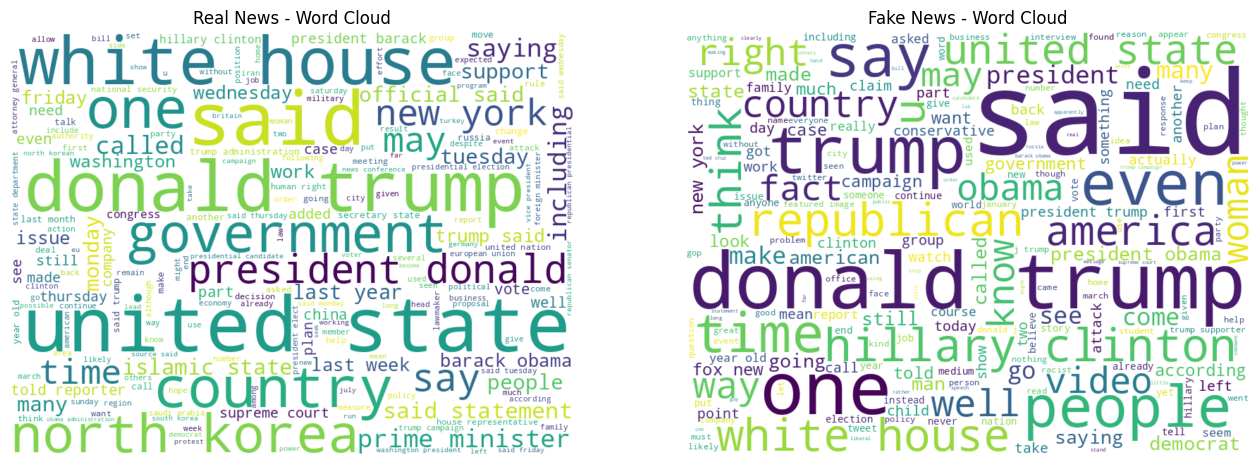

In [10]:
from wordcloud import WordCloud
real_text = ' '.join(tokenized_df[tokenized_df['label'] == 0]['content'])
fake_text = ' '.join(tokenized_df[tokenized_df['label'] == 1]['content'])

real_wordcloud = WordCloud(width=800, height=600, background_color='white').generate(real_text)
fake_wordcloud = WordCloud(width=800, height=600, background_color='white').generate(fake_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(real_wordcloud, interpolation='bilinear')
axes[0].set_title('Real News - Word Cloud')
axes[0].axis('off')

axes[1].imshow(fake_wordcloud, interpolation='bilinear')
axes[1].set_title('Fake News - Word Cloud')
axes[1].axis('off')

plt.show()

The raw merged data showed a near-balanced class split (52.3% fake, 47.7% real) but after removing duplicate articles, it became 53.9% real and 46.1% fake.

There were 6,071 duplicate articles.

**Text Length:**

Real and fake have similar average word counts (371 vs 379)
Fake has higher variance (std 361 vs 276) and longest articles are max (8,289 vs 5,254) long.

**Word Frequency & Word Clouds:**

Real news uses formal, institutional language: "white house", "government", "united state", "official said", "supreme court".

Fake news uses informal, opinion-driven, individual-focused language: "said", "people", "even", "think", "actually".

The word "reuters" appeared almost only in real news (28,435 times) — a wire-service attribution artifact, not real signal, so it was added as a custom stopword to prevent leakage.

---

# Feature Engineering and Representation

Splitting the data set in to 80/10/10 for traning, validating, and testing

In [12]:
from sklearn.model_selection import train_test_split

# split: 80% train, 20% for validate and test
train_df, temp_df = train_test_split(
    tokenized_df,
    test_size=0.20,
    stratify=tokenized_df['label'],
    random_state=42
)

# split: split the 20% into 10% validate and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

print("\nTrain class balance:")
print(train_df['label'].value_counts(normalize=True) * 100)

print("\nValidation class balance:")
print(val_df['label'].value_counts(normalize=True) * 100)

print("\nTest class balance:")
print(test_df['label'].value_counts(normalize=True) * 100)

Train size: 31059
Validation size: 3882
Test size: 3883

Train class balance:
label
0    53.897421
1    46.102579
Name: proportion, dtype: float64

Validation class balance:
label
0    53.889748
1    46.110252
Name: proportion, dtype: float64

Test class balance:
label
0    53.901622
1    46.098378
Name: proportion, dtype: float64


**Save the splited datasets**

In [13]:
train_df.to_csv('data/processed/train.csv', index=False)
validate_df.to_csv('data/processed/validate.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

**TF-IDF on train.csv**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create a TF-IDF vectorizer with 5000 words and including 1 and 2 word terms
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Learn from training text and convert it to numbers
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['content'])

# convert validate and test data to numbers
X_validate_tfidf = tfidf_vectorizer.transform(validate_df['content'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['content'])

print(X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

(31059, 5000) (3882, 5000) (3883, 5000)


In [16]:
print(len(tfidf_vectorizer.vocabulary_))

5000


In [17]:
y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

**saving the fitted vectorizer and matrices for reuse**

In [18]:
import joblib
from scipy.sparse import save_npz

os.makedirs('data/processed/tfidf', exist_ok=True)

joblib.dump(tfidf_vectorizer, 'data/processed/tfidf/tfidf_vectorizer.pkl')

save_npz('data/processed/tfidf/X_train_tfidf.npz', X_train_tfidf)
save_npz('data/processed/tfidf/X_val_tfidf.npz', X_val_tfidf)
save_npz('data/processed/tfidf/X_test_tfidf.npz', X_test_tfidf)